In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import List, Tuple
import time
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import our optimization package
from bayesian_optimizer import BayesianOptimizer
from objective_function import MockObjectiveFunction

# Set up matplotlib for better plots
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")


All imports successful!
PyTorch version: 2.7.1+cu126


In [3]:
## 2. Parameter Space Definition

# Define the 4-dimensional parameter space for our printing process optimization:
# Define parameter bounds
bounds = torch.tensor([
    [0.1, 1.0],      # concentration
    [10.0, 100.0],   # print_speed
    [0.05, 0.5],     # gap_size
    [5.0, 25.0]      # volume
]).T

# Parameter names for plotting
param_names = ['concentration', 'print_speed', 'gap_size', 'volume']
param_units = ['', 'mm/s', 'mm', 'μL']

print("Parameter Space:")
print("=" * 50)
for i, (name, unit) in enumerate(zip(param_names, param_units)):
    lower, upper = bounds[0, i], bounds[1, i]
    unit_str = f" ({unit})" if unit else ""
    print(f"{name:<15} [{lower:>6.2f}, {upper:>6.2f}]{unit_str}")
    
print(f"\nTotal dimensions: {bounds.shape[1]}")


Parameter Space:
concentration   [  0.10,   1.00]
print_speed     [ 10.00, 100.00] (mm/s)
gap_size        [  0.05,   0.50] (mm)
volume          [  5.00,  25.00] (μL)

Total dimensions: 4


In [4]:
## 3. Run Optimization
#Execute the complete Bayesian optimization workflow:
# # Configuration parameters
BATCH_SIZE = 8
N_ITERATIONS = 20
N_INITIAL_POINTS = 10
NOISE_VARIANCE = 0.01
SEED = 42

# Create optimizer and objective function
optimizer = BayesianOptimizer(
    bounds=bounds,
    batch_size=BATCH_SIZE,
    noise_variance=NOISE_VARIANCE,
    seed=SEED
)

objective = MockObjectiveFunction(noise_std=0.1, seed=SEED)

# Get true optimum for comparison
true_params, true_max_score = objective.get_optimal_parameters()
true_score = objective.evaluate_at_optimal()

print("Starting Bayesian Optimization...")
print("=" * 60)
print(f"Batch size: {BATCH_SIZE}")
print(f"Iterations: {N_ITERATIONS}")
print(f"Initial points: {N_INITIAL_POINTS}")
print(f"True optimal score: {true_score:.4f}")

# Run optimization
start_time = time.time()

best_params, best_score = optimizer.optimize(
    objective_function=objective,
    n_iterations=N_ITERATIONS,
    n_initial_points=N_INITIAL_POINTS,
    verbose=True
)

end_time = time.time()
optimization_time = end_time - start_time

print(f"\nOptimization completed in {optimization_time:.2f} seconds")
print(f"Best score: {best_score:.4f}")
print(f"Score gap from true optimum: {(true_score - best_score):.4f}")


Starting Bayesian Optimization...
Batch size: 8
Iterations: 20
Initial points: 10
True optimal score: 0.9993
BAYESIAN OPTIMIZATION STARTING
Parameters: 4 dimensions
Batch size: 8
Iterations: 20
Initial points: 10
Generating 10 initial training points...
Initial best score: 0.4601
Initial best parameters: tensor([ 0.1793, 73.1064,  0.3305, 13.7456], dtype=torch.float64)

Iteration 1/20
----------------------------------------
Fitting GP model...
Optimizing acquisition function...
Evaluating 8 candidates...
Current best score: 0.4601
Current best parameters: tensor([ 0.1793, 73.1064,  0.3305, 13.7456], dtype=torch.float64)

Iteration 2/20
----------------------------------------
Fitting GP model...
Optimizing acquisition function...
Evaluating 8 candidates...
Current best score: 0.4601
Current best parameters: tensor([ 0.1793, 73.1064,  0.3305, 13.7456], dtype=torch.float64)

Iteration 3/20
----------------------------------------
Fitting GP model...
Optimizing acquisition function...
Ev

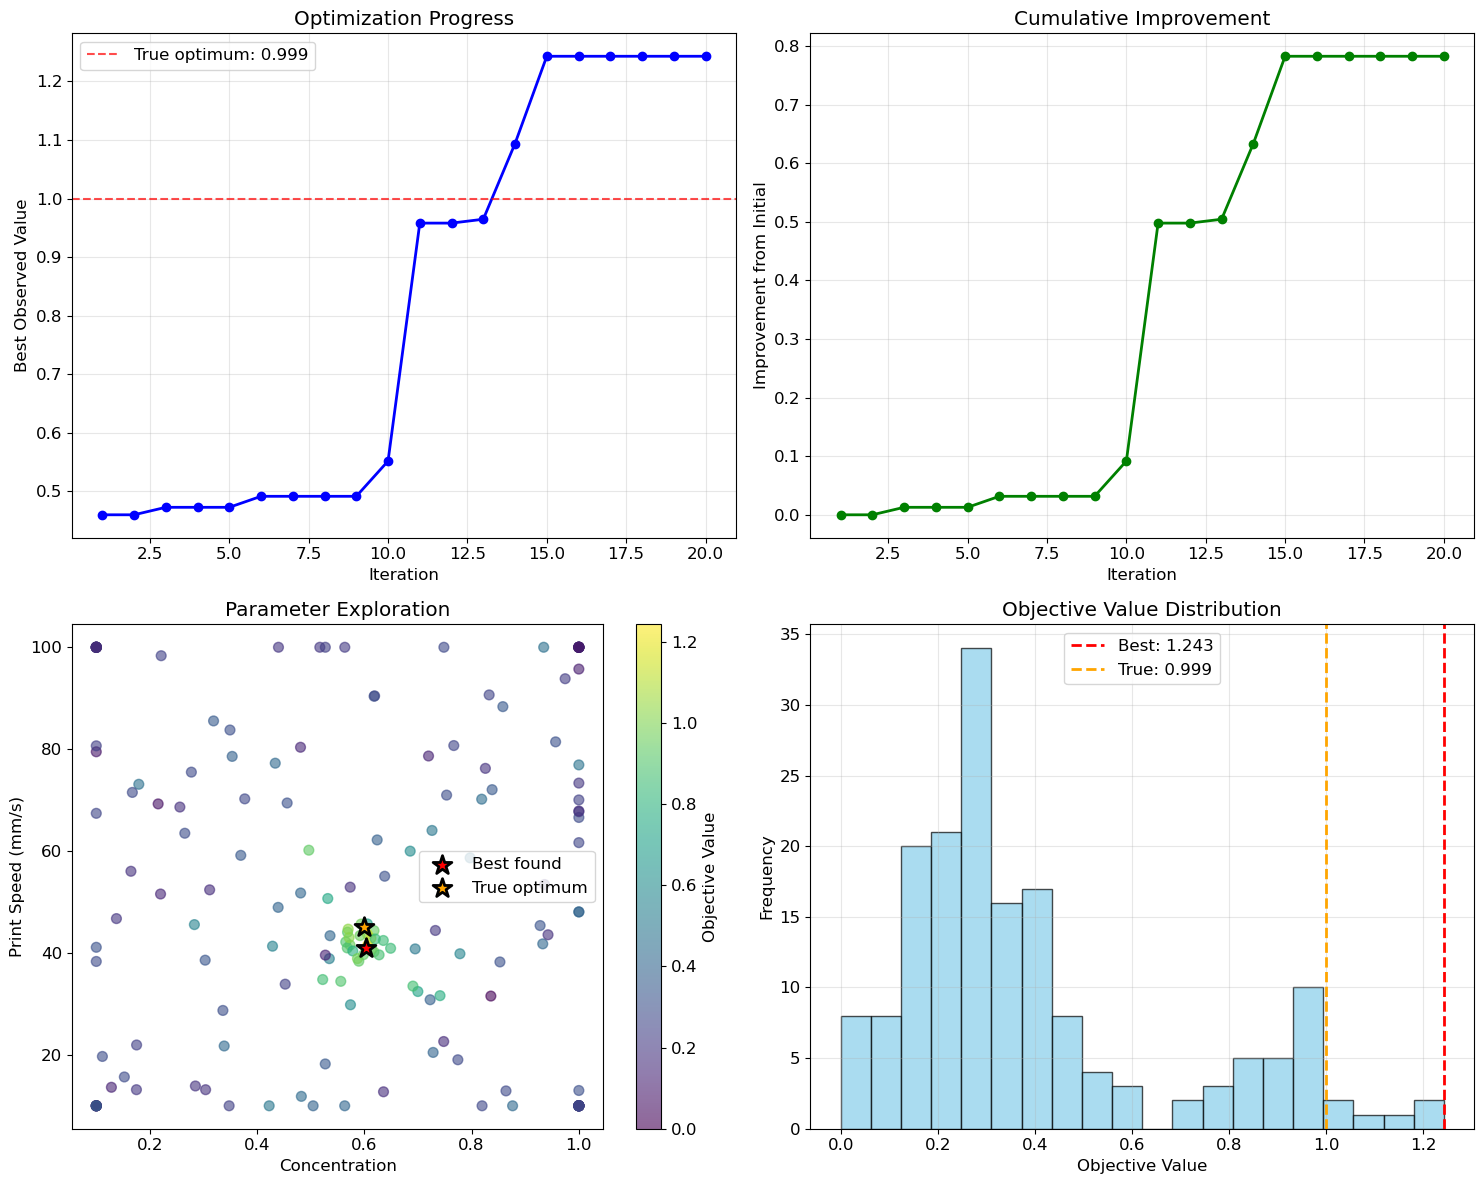

In [5]:
## 4. Results Analysis and Visualization

# Analyze the optimization results and create comprehensive visualizations:
# # Get optimization history and training data
history = optimizer.get_optimization_history()
train_X, train_Y = optimizer.get_training_data()

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Optimization progress
iterations = [h['iteration'] for h in history]
best_values = [h['best_value'] for h in history]

axes[0, 0].plot(iterations, best_values, 'b-o', linewidth=2, markersize=6)
axes[0, 0].axhline(y=true_score, color='r', linestyle='--', alpha=0.7, 
                   label=f'True optimum: {true_score:.3f}')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Best Observed Value')
axes[0, 0].set_title('Optimization Progress')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Improvement over iterations
improvements = [best_values[i] - best_values[0] for i in range(len(best_values))]
axes[0, 1].plot(iterations, improvements, 'g-o', linewidth=2, markersize=6)
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Improvement from Initial')
axes[0, 1].set_title('Cumulative Improvement')
axes[0, 1].grid(True, alpha=0.3)

# 3. Parameter exploration (2D projection)
scatter = axes[1, 0].scatter(train_X[:, 0], train_X[:, 1], c=train_Y.squeeze(), 
                            cmap='viridis', alpha=0.6, s=50)
axes[1, 0].scatter(best_params[0], best_params[1], c='red', s=200, marker='*', 
                  label='Best found', edgecolor='black', linewidth=2)
axes[1, 0].scatter(true_params[0], true_params[1], c='orange', s=200, marker='*', 
                  label='True optimum', edgecolor='black', linewidth=2)
axes[1, 0].set_xlabel('Concentration')
axes[1, 0].set_ylabel('Print Speed (mm/s)')
axes[1, 0].set_title('Parameter Exploration')
axes[1, 0].legend()
plt.colorbar(scatter, ax=axes[1, 0], label='Objective Value')

# 4. Objective value distribution
axes[1, 1].hist(train_Y.squeeze().numpy(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 1].axvline(best_score, color='red', linestyle='--', linewidth=2, label=f'Best: {best_score:.3f}')
axes[1, 1].axvline(true_score, color='orange', linestyle='--', linewidth=2, label=f'True: {true_score:.3f}')
axes[1, 1].set_xlabel('Objective Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Objective Value Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
